# 27 — Validate Simulation: RevPAR · What-if · Elasticity · Optimal · Back-test

> **Đầu vào:** `hotel_bookings_v5.csv` · panel/ε `22` · rate plan `23` · ensemble `24`
> **Đầu ra:** `reports/figures/27_validate_simulation/`

| Block | Nội dung |
|-------|----------|
| 1 | RevPAR simulation: baseline vs dynamic pricing |
| 2 | What-if: Peak ADR +10% (ladder 5/10/15%) |
| 3 | Price elasticity by segment (+ ε_ops) |
| 4 | Optimal point: revenue × cancel risk |
| 5 | Back-test pricing rules 2015–2016 |


In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from numpy.linalg import lstsq

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
})
COLORS = {
    "teal": "#264653",
    "cyan": "#2A9D8F",
    "gold": "#E9C46A",
    "orange": "#F4A261",
    "coral": "#E76F51",
    "blue": "#0072B2",
    "sky": "#56B4E9",
    "gray": "#8C8C8C",
}
OUR, BASE = COLORS["coral"], COLORS["gray"]

NOTEBOOK_DIR = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "data").is_dir() else NOTEBOOK_DIR
if not (ROOT / "data").is_dir():
    ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "hotel_bookings_v5.csv"
FIG_DIR = ROOT / "reports" / "figures" / "27_validate_simulation"
FIG_DIR.mkdir(parents=True, exist_ok=True)
for slug in ("city", "resort", "compare", "tables"):
    (FIG_DIR / slug).mkdir(parents=True, exist_ok=True)

MONTH_MAP = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}
HOTELS = ["City Hotel", "Resort Hotel"]
PEAK_MONTHS = {7, 8}
SHOULDER_MONTHS = {4, 5, 6, 9, 10}
EPS_PRIOR = {"City Hotel": -0.70, "Resort Hotel": -1.10}

print(f"ROOT: {ROOT}")
print(f"DATA: {DATA_PATH}")
print(f"FIG_DIR: {FIG_DIR}")


ROOT: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python
DATA: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
FIG_DIR: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\reports\figures\27_validate_simulation


In [2]:
def savefig(name: str, slug: str | None = None, dpi: int = 140) -> Path:
    folder = FIG_DIR if slug is None else FIG_DIR / slug
    folder.mkdir(parents=True, exist_ok=True)
    path = folder / name
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    try:
        plt.show()
    except Exception:
        plt.close()
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def season_of(month: int) -> str:
    if month in PEAK_MONTHS:
        return "Peak"
    if month in SHOULDER_MONTHS:
        return "Shoulder"
    return "Low"


def q_local_linear(p, p0, q0, eps, q_floor_mult=0.05, q_cap_mult=1.15):
    """Local-linear demand around (p0, q0); same family as notebook 23."""
    p = np.asarray(p, dtype=float)
    demand = q0 * (1.0 + eps * (p - p0) / p0)
    demand = np.clip(demand, q_floor_mult * q0, None)
    return np.minimum(demand, q_cap_mult * q0)


def revenue_at(p, p0, q0, eps):
    q = q_local_linear(p, p0, q0, eps)
    return p * q, q


def optimize_month(p0, q0, eps, pressure=1.0, lo_mult=0.70, hi_mult=1.30, n_grid=161):
    p_ref = p0 * float(np.clip(0.70 + 0.30 * pressure, 0.80, 1.20))
    prices = np.linspace(p0 * lo_mult, p0 * hi_mult, n_grid)
    rev, q = revenue_at(prices, p0, q0, eps)
    i = int(np.argmax(rev))
    p_analytic = p0 * (eps - 1.0) / (2.0 * eps) if eps < 0 else p_ref
    return {
        "p_star": float(prices[i]),
        "q_star": float(q[i]),
        "rev_star": float(rev[i]),
        "rev_baseline": float(p0 * min(q0, 1.15 * q0)),
        "p_analytic": float(p_analytic),
        "grid_prices": prices,
        "grid_revenue": rev,
        "grid_demand": q,
    }


def action_from_delta(delta_p: float) -> str:
    if delta_p >= 3:
        return "RAISE"
    if delta_p <= -3:
        return "CUT"
    return "HOLD"


## 0. Load artifacts and build panels


In [3]:
panel_path = ROOT / "reports" / "figures" / "22_elasticity" / "monthly_panel.csv"
elas_path = ROOT / "reports" / "figures" / "22_elasticity" / "elasticity_by_hotel.csv"
opt_path = ROOT / "reports" / "figures" / "23_optimization" / "optimal_rate_plan.csv"
ens_path = ROOT / "reports" / "figures" / "24_ml_pricing" / "ensemble_rate_recommend.csv"

panel = pd.read_csv(panel_path, parse_dates=["ym"])
panel["season"] = panel["ym"].dt.month.map(season_of)
elas = pd.read_csv(elas_path)
opt = pd.read_csv(opt_path, parse_dates=["ym"]) if opt_path.exists() else None
ens = pd.read_csv(ens_path, parse_dates=["ym"]) if ens_path.exists() else None

usecols = [
    "hotel", "is_canceled", "adr", "arrival_date_year", "arrival_date_month",
    "Occupancy_Rate", "RevPAR", "market_segment", "customer_type",
    "lead_time", "stays_in_weekend_nights", "stays_in_week_nights",
]
raw = pd.read_csv(DATA_PATH, usecols=usecols)
raw["month"] = raw["arrival_date_month"].map(MONTH_MAP)
raw["ym"] = pd.to_datetime(dict(year=raw["arrival_date_year"], month=raw["month"], day=1))
raw["los"] = raw["stays_in_weekend_nights"] + raw["stays_in_week_nights"]
raw["season"] = raw["month"].map(season_of)

cancel_m = (
    raw.groupby(["hotel", "ym"], as_index=False)
    .agg(
        n_bookings=("is_canceled", "size"),
        cancel_rate=("is_canceled", "mean"),
        adr_all=("adr", "mean"),
    )
)
panel = panel.merge(cancel_m, on=["hotel", "ym"], how="left")
stay = raw[(raw["is_canceled"] == 0) & (raw["adr"] > 0)].copy()

print("panel:", panel.shape, panel["ym"].min().date(), "->", panel["ym"].max().date())
print("elas:")
display(elas)
if opt is not None:
    print("opt rows:", len(opt))
if ens is not None:
    print("ensemble rows:", len(ens))
display(panel.head(3))


panel: (52, 21) 2015-07-01 -> 2017-08-01
elas:


,hotel,elasticity_primary,source_method,elasticity_loglog,elasticity_fd,elasticity_segment,note
0,City Hotel,-0.7,rm_prior,3.502343,1.925701,3.317039,OLS biased positive (seasonality/endogeneity) ...
1,Resort Hotel,-1.1,rm_prior,0.405544,0.112803,1.074147,OLS biased positive (seasonality/endogeneity) ...


opt rows: 12
ensemble rows: 12


,hotel,ym,demand,adr,occ,revpar,lead_mean,lead_p50,los_mean,special_req,...,share_groups,share_transient,month,log_demand,log_adr,log_revpar,season,n_bookings,cancel_rate,adr_all
0,City Hotel,2015-07-01,102,73.793235,0.383686,22.739909,83.921569,71.5,3.245098,0.215686,...,0.441176,0.382353,7,4.624973,4.301267,3.124122,Peak,331,0.616314,66.777311
1,City Hotel,2015-08-01,725,91.702041,0.787726,66.885292,25.812414,4.0,3.046897,0.805517,...,0.077241,0.532414,8,6.586172,4.518545,4.202979,Peak,994,0.212274,83.527586
2,City Hotel,2015-09-01,1119,114.382377,0.814583,88.884639,29.806971,15.0,2.997319,0.671135,...,0.128686,0.474531,9,7.020191,4.739547,4.487339,Shoulder,1440,0.185417,108.543472


## 1. RevPAR Simulation — baseline vs dynamic pricing


,hotel,season,n,mean_delta_revpar_pct,mean_delta_rev_pct,mean_delta_adr_pct,mean_revpar_base,mean_revpar_sim
0,City Hotel,Low,10,3.21,3.21,21.38,64.96,67.05
1,City Hotel,Peak,6,3.21,3.21,21.38,74.44,76.83
2,City Hotel,Shoulder,10,3.21,3.21,21.38,83.46,86.14
3,Resort Hotel,Low,10,0.23,0.23,-4.50,46.72,46.82
4,Resort Hotel,Peak,6,0.23,0.23,-4.50,115.44,115.70
5,Resort Hotel,Shoulder,10,0.23,0.23,-4.50,65.81,65.96


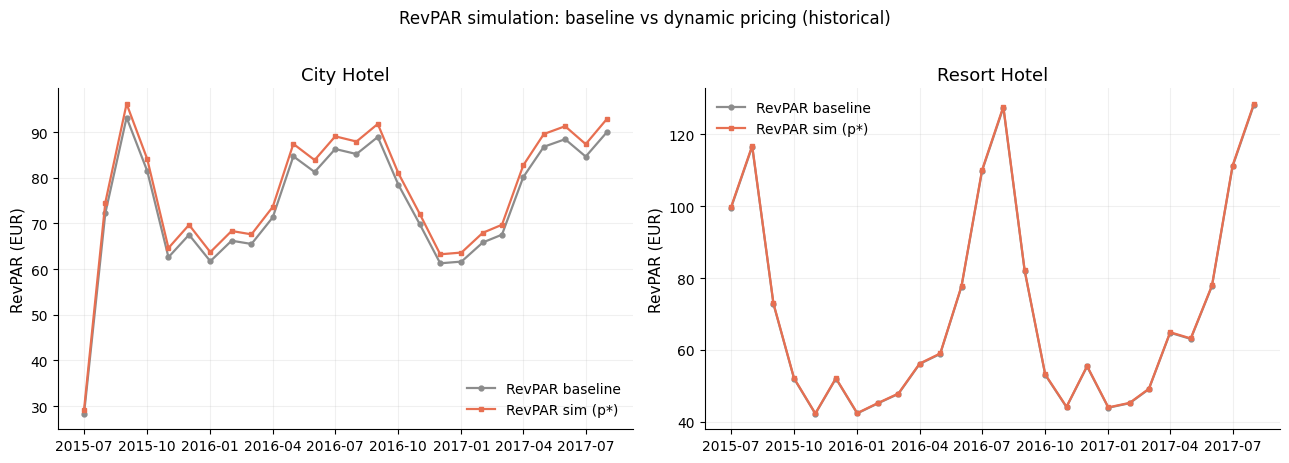

Saved: reports\figures\27_validate_simulation\compare\01_revpar_base_vs_sim.png


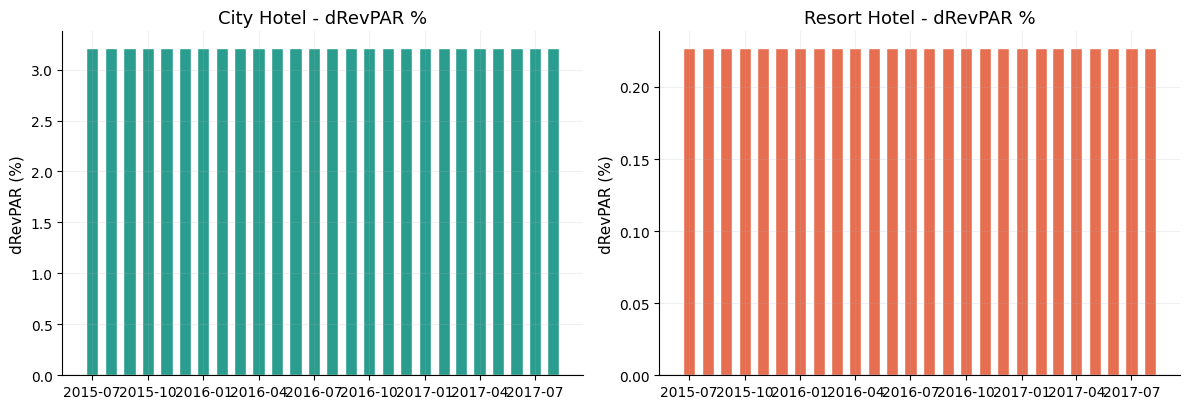

Saved: reports\figures\27_validate_simulation\compare\02_delta_revpar_pct.png


WindowsPath('c:/Users/ADMIN/OneDrive/Tài liệu/oneDrive/Desktop/DA/Project/Hotel Booking Demand/Python/reports/figures/27_validate_simulation/compare/02_delta_revpar_pct.png')

In [4]:
sim_rows = []
for _, r in panel.iterrows():
    hotel = r["hotel"]
    eps = float(EPS_PRIOR[hotel])
    p0 = float(r["adr"])
    q0 = float(r["demand"])
    out = optimize_month(p0, q0, eps, pressure=1.0)
    rev_base = p0 * q0
    rev_sim = out["rev_star"]
    occ0 = float(r["occ"])
    # Consistent proxy: ADR * Occ (panel RevPAR mean can differ from adr*occ)
    revpar_base = p0 * occ0
    occ_sim = float(np.clip(occ0 * (out["q_star"] / q0), 0.05, 0.99))
    revpar_sim = out["p_star"] * occ_sim
    sim_rows.append({
        "hotel": hotel,
        "ym": r["ym"],
        "season": r["season"],
        "eps": eps,
        "adr_base": p0,
        "demand_base": q0,
        "occ_base": occ0,
        "revpar_panel": float(r["revpar"]),
        "revpar_base": revpar_base,
        "cancel_rate": float(r["cancel_rate"]),
        "p_star": out["p_star"],
        "q_star": out["q_star"],
        "occ_sim": occ_sim,
        "revpar_sim": revpar_sim,
        "rev_base": rev_base,
        "rev_sim": rev_sim,
        "delta_adr_pct": (out["p_star"] / p0 - 1) * 100,
        "delta_rev_pct": (rev_sim / rev_base - 1) * 100,
        "delta_revpar_pct": (revpar_sim / revpar_base - 1) * 100 if revpar_base else np.nan,
        "action": action_from_delta((out["p_star"] / p0 - 1) * 100),
    })

sim = pd.DataFrame(sim_rows).sort_values(["hotel", "ym"]).reset_index(drop=True)
sim.to_csv(FIG_DIR / "tables" / "revpar_simulation_monthly.csv", index=False)

summary_sim = (
    sim.groupby(["hotel", "season"], as_index=False)
    .agg(
        n=("ym", "size"),
        mean_delta_revpar_pct=("delta_revpar_pct", "mean"),
        mean_delta_rev_pct=("delta_rev_pct", "mean"),
        mean_delta_adr_pct=("delta_adr_pct", "mean"),
        mean_revpar_base=("revpar_base", "mean"),
        mean_revpar_sim=("revpar_sim", "mean"),
    )
)
display(summary_sim.round(2))
summary_sim.to_csv(FIG_DIR / "tables" / "revpar_simulation_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, hotel in zip(axes, HOTELS):
    sub = sim[sim["hotel"] == hotel]
    ax.plot(sub["ym"], sub["revpar_base"], color=BASE, marker="o", ms=3.5, lw=1.6, label="RevPAR baseline")
    ax.plot(sub["ym"], sub["revpar_sim"], color=OUR, marker="s", ms=3.5, lw=1.6, label="RevPAR sim (p*)")
    ax.set_title(hotel)
    ax.set_ylabel("RevPAR (EUR)")
    ax.legend(frameon=False)
fig.suptitle("RevPAR simulation: baseline vs dynamic pricing (historical)", y=1.02)
savefig("01_revpar_base_vs_sim.png", "compare")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, hotel in zip(axes, HOTELS):
    sub = sim[sim["hotel"] == hotel]
    colors = [
        COLORS["cyan"] if a == "RAISE" else (COLORS["coral"] if a == "CUT" else COLORS["gold"])
        for a in sub["action"]
    ]
    ax.bar(sub["ym"], sub["delta_revpar_pct"], width=20, color=colors, edgecolor="white")
    ax.axhline(0, color="#333", lw=0.8)
    ax.set_title(f"{hotel} - dRevPAR %")
    ax.set_ylabel("dRevPAR (%)")
savefig("02_delta_revpar_pct.png", "compare")


## 2. What-if — Peak ADR +10% (ladder 5 / 10 / 15%)


,hotel,market_segment,shock_pct,n_stay,n_bookings,eps,adr_base,adr_shock,demand_base,demand_shock,delta_demand_pct,rev_base,rev_shock,delta_rev_pct,revpar_panel,revpar_base,revpar_shock,delta_revpar_pct,cancel_rate
10,City Hotel,Complementary,10.0,1,71,-0.7,35.00,38.50,1.0,0.93,-7.0,35.00,35.80,2.3,84.59,25.28,25.86,2.3,0.07
15,City Hotel,Online TA,10.0,5290,8557,-0.7,131.86,145.05,5290.0,4919.70,-7.0,697538.00,713581.37,2.3,83.48,89.39,91.45,2.3,0.38
11,City Hotel,Corporate,10.0,223,264,-0.7,80.18,88.20,223.0,207.39,-7.0,17879.96,18291.20,2.3,82.70,54.83,56.09,2.3,0.15
12,City Hotel,Direct,10.0,1163,1407,-0.7,133.99,147.39,1163.0,1081.59,-7.0,155826.73,159410.74,2.3,82.46,91.98,94.10,2.3,0.16
13,City Hotel,Groups,10.0,154,349,-0.7,84.03,92.43,154.0,143.22,-7.0,12940.00,13237.62,2.3,60.54,52.71,53.93,2.3,0.46
14,City Hotel,Offline TA/TO,10.0,945,1196,-0.7,93.49,102.84,945.0,878.85,-7.0,88352.02,90384.12,2.3,82.96,62.80,64.25,2.3,0.19
18,Resort Hotel,Offline TA/TO,10.0,1433,1720,-1.1,124.45,136.90,1433.0,1275.37,-11.0,178340.73,174595.57,-2.1,113.08,86.61,84.79,-2.1,0.16
17,Resort Hotel,Direct,10.0,1383,1737,-1.1,190.81,209.89,1383.0,1230.87,-11.0,263894.59,258352.80,-2.1,114.39,131.40,128.64,-2.1,0.19
16,Resort Hotel,Corporate,10.0,82,134,-1.1,129.99,142.98,82.0,72.98,-11.0,10658.82,10434.98,-2.1,110.10,90.69,88.79,-2.1,0.36
19,Resort Hotel,Online TA,10.0,3017,5171,-1.1,183.57,201.93,3017.0,2685.13,-11.0,553827.05,542196.68,-2.1,114.63,125.58,122.95,-2.1,0.41


,hotel,delta_revpar_pct,delta_demand_pct,delta_rev_pct
0,City Hotel,2.3,-7.0,2.3
1,Resort Hotel,-2.1,-11.0,-2.1


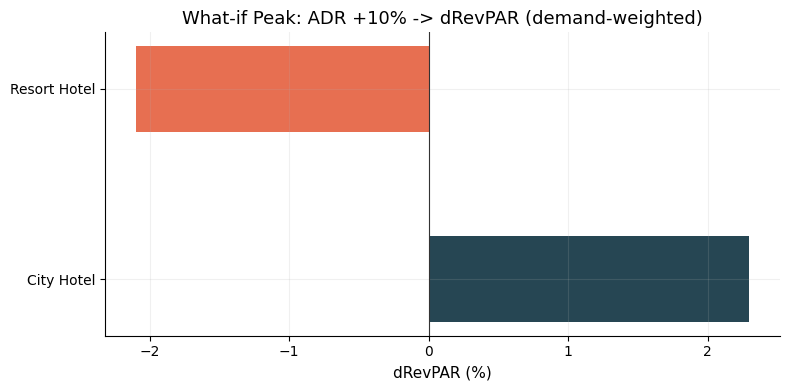

Saved: reports\figures\27_validate_simulation\compare\03_whatif_peak10_tornado.png


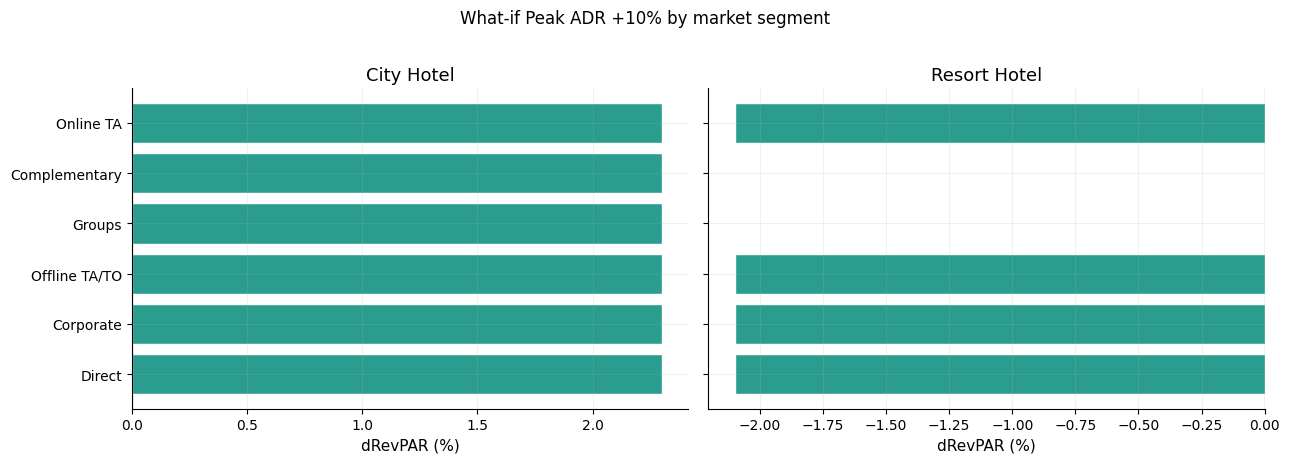

Saved: reports\figures\27_validate_simulation\compare\04_whatif_peak10_by_segment.png


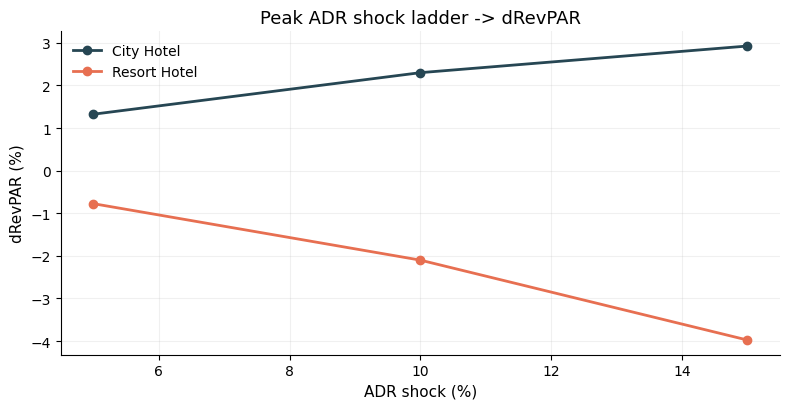

Saved: reports\figures\27_validate_simulation\compare\05_whatif_peak_ladder.png


WindowsPath('c:/Users/ADMIN/OneDrive/Tài liệu/oneDrive/Desktop/DA/Project/Hotel Booking Demand/Python/reports/figures/27_validate_simulation/compare/05_whatif_peak_ladder.png')

In [5]:
def whatif_shock(df_stay: pd.DataFrame, shock: float, eps_map: dict) -> pd.DataFrame:
    rows = []
    peak = df_stay[df_stay["season"] == "Peak"].copy()
    gcols = ["hotel", "market_segment"]
    agg = (
        peak.groupby(gcols, as_index=False)
        .agg(
            demand=("adr", "size"),
            adr=("adr", "mean"),
            occ=("Occupancy_Rate", "mean"),
            revpar=("RevPAR", "mean"),
        )
    )
    peak_all = raw[raw["season"] == "Peak"]
    cxl = peak_all.groupby(gcols, as_index=False).agg(
        cancel_rate=("is_canceled", "mean"),
        n=("is_canceled", "size"),
    )
    agg = agg.merge(cxl, on=gcols, how="left")
    for _, r in agg.iterrows():
        if r["n"] < 30:
            continue
        hotel = r["hotel"]
        eps = float(eps_map[hotel])
        p0, q0 = float(r["adr"]), float(r["demand"])
        p1 = p0 * (1.0 + shock)
        rev1, q1 = revenue_at(p1, p0, q0, eps)
        occ0 = float(r["occ"])
        revpar0 = p0 * occ0
        occ1 = float(np.clip(occ0 * (q1 / q0), 0.05, 0.99))
        revpar1 = p1 * occ1
        rows.append({
            "hotel": hotel,
            "market_segment": r["market_segment"],
            "shock_pct": shock * 100,
            "n_stay": int(r["demand"]),
            "n_bookings": int(r["n"]),
            "eps": eps,
            "adr_base": p0,
            "adr_shock": p1,
            "demand_base": q0,
            "demand_shock": float(q1),
            "delta_demand_pct": (q1 / q0 - 1) * 100,
            "rev_base": p0 * q0,
            "rev_shock": float(rev1),
            "delta_rev_pct": (rev1 / (p0 * q0) - 1) * 100,
            "revpar_panel": float(r["revpar"]),
            "revpar_base": revpar0,
            "revpar_shock": revpar1,
            "delta_revpar_pct": (revpar1 / revpar0 - 1) * 100 if revpar0 else np.nan,
            "cancel_rate": float(r["cancel_rate"]),
        })
    return pd.DataFrame(rows)


whatif = pd.concat(
    [whatif_shock(stay, s, EPS_PRIOR) for s in (0.05, 0.10, 0.15)],
    ignore_index=True,
)
whatif.to_csv(FIG_DIR / "tables" / "whatif_peak_adr_ladder.csv", index=False)

w10 = whatif[whatif["shock_pct"] == 10].sort_values(
    ["hotel", "delta_revpar_pct"], ascending=[True, False]
)
display(w10.round(2))

hp_rows = []
for hotel, d in whatif[whatif["shock_pct"] == 10].groupby("hotel"):
    w = d["n_stay"].to_numpy()
    hp_rows.append({
        "hotel": hotel,
        "delta_revpar_pct": np.average(d["delta_revpar_pct"], weights=w),
        "delta_demand_pct": np.average(d["delta_demand_pct"], weights=w),
        "delta_rev_pct": np.average(d["delta_rev_pct"], weights=w),
    })
hotel_peak = pd.DataFrame(hp_rows)
display(hotel_peak.round(2))
hotel_peak.to_csv(FIG_DIR / "tables" / "whatif_peak_plus10_hotel.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(hotel_peak))
ax.barh(y, hotel_peak["delta_revpar_pct"], color=[COLORS["teal"], COLORS["coral"]], height=0.45)
ax.set_yticks(y)
ax.set_yticklabels(hotel_peak["hotel"])
ax.axvline(0, color="#333", lw=0.8)
ax.set_xlabel("dRevPAR (%)")
ax.set_title("What-if Peak: ADR +10% -> dRevPAR (demand-weighted)")
savefig("03_whatif_peak10_tornado.png", "compare")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, hotel in zip(axes, HOTELS):
    sub = w10[w10["hotel"] == hotel].sort_values("delta_revpar_pct")
    ax.barh(sub["market_segment"], sub["delta_revpar_pct"], color=COLORS["cyan"], edgecolor="white")
    ax.axvline(0, color="#333", lw=0.8)
    ax.set_title(hotel)
    ax.set_xlabel("dRevPAR (%)")
fig.suptitle("What-if Peak ADR +10% by market segment", y=1.02)
savefig("04_whatif_peak10_by_segment.png", "compare")

ladder_rows = []
for shock in (5, 10, 15):
    for hotel, d in whatif[whatif["shock_pct"] == shock].groupby("hotel"):
        w = d["n_stay"].to_numpy()
        ladder_rows.append({
            "hotel": hotel,
            "shock_pct": shock,
            "delta_revpar_pct": np.average(d["delta_revpar_pct"], weights=w),
            "delta_demand_pct": np.average(d["delta_demand_pct"], weights=w),
        })
ladder = pd.DataFrame(ladder_rows)
fig, ax = plt.subplots(figsize=(8, 4.2))
for hotel, color in zip(HOTELS, [COLORS["teal"], COLORS["coral"]]):
    sub = ladder[ladder["hotel"] == hotel]
    ax.plot(sub["shock_pct"], sub["delta_revpar_pct"], marker="o", lw=2, color=color, label=hotel)
ax.set_xlabel("ADR shock (%)")
ax.set_ylabel("dRevPAR (%)")
ax.set_title("Peak ADR shock ladder -> dRevPAR")
ax.legend(frameon=False)
savefig("05_whatif_peak_ladder.png", "compare")


## 3. Price elasticity by segment


,hotel,market_segment,elasticity_hat,se,n_months,r2,elasticity_ops,source,label
0,City Hotel,Corporate,3.361,1.699,26,0.567,-0.700,rm_prior,inelastic
1,City Hotel,Direct,1.007,0.326,25,0.811,-0.700,rm_prior,inelastic
3,City Hotel,Offline TA/TO,0.871,1.733,26,0.357,-0.700,rm_prior,inelastic
4,City Hotel,Online TA,4.543,0.606,26,0.857,-0.700,rm_prior,inelastic
2,City Hotel,Groups,-0.421,1.297,26,0.565,-0.421,loglog_month_fe,inelastic
8,Resort Hotel,Offline TA/TO,-2.242,0.386,26,0.904,-2.242,loglog_month_fe,elastic
5,Resort Hotel,Corporate,0.471,0.386,26,0.972,-1.100,rm_prior,elastic
6,Resort Hotel,Direct,0.342,0.259,26,0.807,-1.100,rm_prior,elastic
9,Resort Hotel,Online TA,0.831,0.486,26,0.548,-1.100,rm_prior,elastic
7,Resort Hotel,Groups,-0.398,1.111,24,0.906,-0.398,loglog_month_fe,inelastic


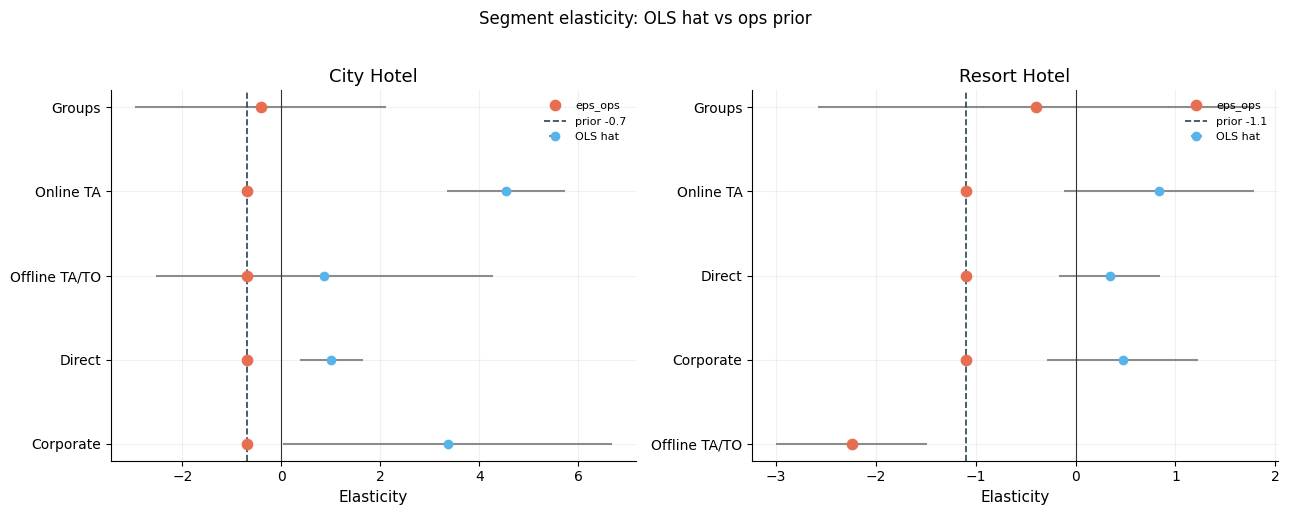

Saved: reports\figures\27_validate_simulation\compare\06_elasticity_segment_forest.png


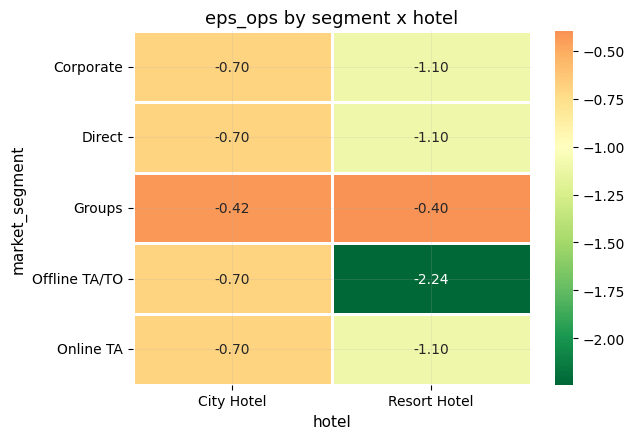

Saved: reports\figures\27_validate_simulation\compare\07_elasticity_ops_heatmap.png


WindowsPath('c:/Users/ADMIN/OneDrive/Tài liệu/oneDrive/Desktop/DA/Project/Hotel Booking Demand/Python/reports/figures/27_validate_simulation/compare/07_elasticity_ops_heatmap.png')

In [6]:
def ols_loglog_month_fe(df: pd.DataFrame) -> dict:
    d = df.dropna(subset=["log_demand", "log_adr"]).copy()
    if len(d) < 8:
        return {"elasticity": np.nan, "se": np.nan, "n": len(d), "r2": np.nan}
    y = d["log_demand"].to_numpy()
    month_dummies = pd.get_dummies(d["month"], prefix="m", drop_first=True)
    X = np.column_stack([
        np.ones(len(d)),
        d["log_adr"].to_numpy(),
        month_dummies.to_numpy(dtype=float),
    ])
    beta, *_ = lstsq(X, y, rcond=None)
    yhat = X @ beta
    resid = y - yhat
    dof = max(len(y) - X.shape[1], 1)
    sigma2 = float(resid @ resid) / dof
    try:
        xtx_inv = np.linalg.inv(X.T @ X)
        se = float(np.sqrt(sigma2 * xtx_inv[1, 1]))
    except np.linalg.LinAlgError:
        se = np.nan
    ss_tot = float(((y - y.mean()) ** 2).sum())
    r2 = 1.0 - float((resid @ resid) / ss_tot) if ss_tot > 0 else np.nan
    return {"elasticity": float(beta[1]), "se": se, "n": int(len(d)), "r2": r2}


seg_panel = (
    stay.groupby(["hotel", "market_segment", "ym"], as_index=False)
    .agg(demand=("adr", "size"), adr=("adr", "mean"))
)
seg_panel["month"] = seg_panel["ym"].dt.month
seg_panel["log_demand"] = np.log(seg_panel["demand"].clip(lower=1))
seg_panel["log_adr"] = np.log(seg_panel["adr"].clip(lower=1e-3))

elas_seg_rows = []
for (hotel, seg), g in seg_panel.groupby(["hotel", "market_segment"]):
    if g["demand"].sum() < 200 or len(g) < 8:
        continue
    est = ols_loglog_month_fe(g)
    eps_hat = est["elasticity"]
    prior = EPS_PRIOR[hotel]
    use_prior = (not np.isfinite(eps_hat)) or (eps_hat >= 0) or (est["n"] < 10)
    eps_ops = prior if use_prior else float(eps_hat)
    elas_seg_rows.append({
        "hotel": hotel,
        "market_segment": seg,
        "elasticity_hat": eps_hat,
        "se": est["se"],
        "n_months": est["n"],
        "r2": est["r2"],
        "elasticity_ops": eps_ops,
        "source": "rm_prior" if use_prior else "loglog_month_fe",
        "label": "inelastic" if abs(eps_ops) < 1 else "elastic",
    })

elas_seg = pd.DataFrame(elas_seg_rows).sort_values(["hotel", "elasticity_ops"])
elas_seg.to_csv(FIG_DIR / "tables" / "elasticity_by_segment.csv", index=False)
display(elas_seg.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, hotel in zip(axes, HOTELS):
    sub = elas_seg[elas_seg["hotel"] == hotel].copy()
    if sub.empty:
        ax.set_visible(False)
        continue
    yy = np.arange(len(sub))
    ax.errorbar(
        sub["elasticity_hat"], yy,
        xerr=1.96 * sub["se"].fillna(0),
        fmt="o", color=COLORS["sky"], ecolor=COLORS["gray"],
        label="OLS hat",
    )
    ax.scatter(sub["elasticity_ops"], yy, color=OUR, s=55, zorder=3, label="eps_ops")
    ax.axvline(0, color="#333", lw=0.8)
    ax.axvline(EPS_PRIOR[hotel], color=COLORS["teal"], ls="--", lw=1.2, label=f"prior {EPS_PRIOR[hotel]}")
    ax.set_yticks(yy)
    ax.set_yticklabels(sub["market_segment"])
    ax.set_xlabel("Elasticity")
    ax.set_title(hotel)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Segment elasticity: OLS hat vs ops prior", y=1.02)
savefig("06_elasticity_segment_forest.png", "compare")

piv = elas_seg.pivot(index="market_segment", columns="hotel", values="elasticity_ops")
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.heatmap(piv, annot=True, fmt=".2f", cmap="RdYlGn_r", center=-1.0, ax=ax, linewidths=1, linecolor="white")
ax.set_title("eps_ops by segment x hotel")
savefig("07_elasticity_ops_heatmap.png", "compare")


## 4. Optimal pricing point — revenue x cancel risk


d(cancel_rate)/d(log ADR) descriptive: {'City Hotel': 0.06919166197206301, 'Resort Hotel': 0.1451489633565411}


,delta_dual_vs_rev_pct,risk_revopt,risk_dual
hotel,,,
City Hotel,-8.342,0.315,0.309
Resort Hotel,-7.461,0.222,0.211


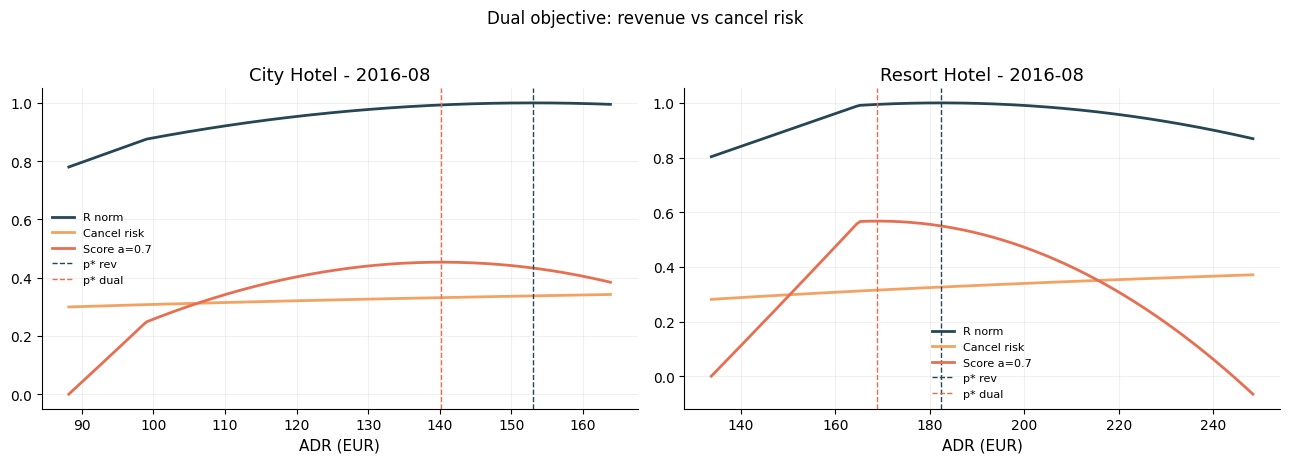

Saved: reports\figures\27_validate_simulation\compare\08_dual_objective_curves.png


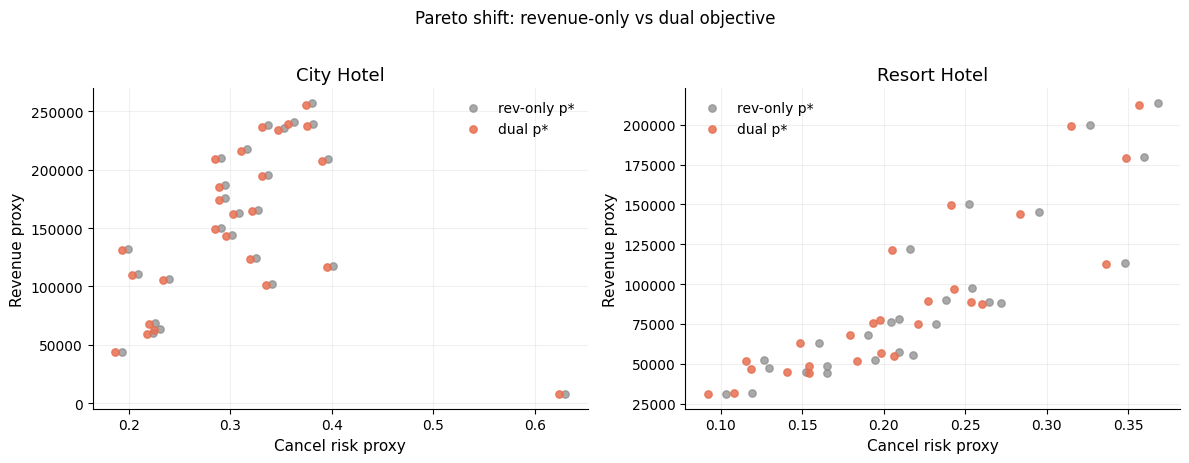

Saved: reports\figures\27_validate_simulation\compare\09_pareto_rev_vs_risk.png


,hotel,alpha,p_star_dual,risk,rev,ym
0,City Hotel,0.5,117.51,0.32,225205.79,2016-08-01
1,City Hotel,0.7,140.19,0.33,236351.23,2016-08-01
2,City Hotel,0.9,150.12,0.34,237938.01,2016-08-01
3,Resort Hotel,0.5,165.28,0.31,198363.65,2016-08-01
4,Resort Hotel,0.7,168.86,0.31,199023.97,2016-08-01
5,Resort Hotel,0.9,178.89,0.32,200051.28,2016-08-01


In [7]:
risk_slope = {}
for hotel, g in panel.groupby("hotel"):
    x = np.log(g["adr"].clip(lower=1e-3)).to_numpy()
    y = g["cancel_rate"].to_numpy()
    if len(g) >= 8 and np.std(x) > 0:
        b = np.polyfit(x, y, 1)[0]
    else:
        b = 0.05
    risk_slope[hotel] = float(b)

print("d(cancel_rate)/d(log ADR) descriptive:", risk_slope)


def dual_optimize(p0, q0, eps, cancel0, slope, alpha=0.7, lo_mult=0.70, hi_mult=1.30, n_grid=161):
    prices = np.linspace(p0 * lo_mult, p0 * hi_mult, n_grid)
    rev, q = revenue_at(prices, p0, q0, eps)
    risk = cancel0 + slope * np.log(prices / p0)
    risk = np.clip(risk, 0.01, 0.95)
    r_norm = (rev - rev.min()) / (rev.max() - rev.min() + 1e-12)
    k_norm = (risk - risk.min()) / (risk.max() - risk.min() + 1e-12)
    score = alpha * r_norm - (1 - alpha) * k_norm
    i = int(np.argmax(score))
    i_rev = int(np.argmax(rev))
    return {
        "prices": prices,
        "revenue": rev,
        "risk": risk,
        "score": score,
        "p_star_rev": float(prices[i_rev]),
        "p_star_dual": float(prices[i]),
        "rev_at_dual": float(rev[i]),
        "risk_at_dual": float(risk[i]),
        "rev_at_revopt": float(rev[i_rev]),
        "risk_at_revopt": float(risk[i_rev]),
        "alpha": alpha,
    }


dual_rows = []
ALPHAS = [0.5, 0.7, 0.9]
for _, r in panel.iterrows():
    hotel = r["hotel"]
    out = dual_optimize(
        float(r["adr"]), float(r["demand"]), EPS_PRIOR[hotel],
        float(r["cancel_rate"]), risk_slope[hotel], alpha=0.7,
    )
    dual_rows.append({
        "hotel": hotel,
        "ym": r["ym"],
        "season": r["season"],
        "p0": float(r["adr"]),
        "cancel0": float(r["cancel_rate"]),
        "p_star_rev": out["p_star_rev"],
        "p_star_dual": out["p_star_dual"],
        "delta_dual_vs_rev_pct": (out["p_star_dual"] / out["p_star_rev"] - 1) * 100,
        "risk_revopt": out["risk_at_revopt"],
        "risk_dual": out["risk_at_dual"],
        "rev_revopt": out["rev_at_revopt"],
        "rev_dual": out["rev_at_dual"],
    })

dual = pd.DataFrame(dual_rows)
dual.to_csv(FIG_DIR / "tables" / "optimal_dual_monthly.csv", index=False)
display(dual.groupby("hotel")[["delta_dual_vs_rev_pct", "risk_revopt", "risk_dual"]].mean().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, hotel in zip(axes, HOTELS):
    peak = panel[(panel["hotel"] == hotel) & (panel["season"] == "Peak")]
    r = peak.sort_values("demand").iloc[-1]
    out = dual_optimize(
        float(r["adr"]), float(r["demand"]), EPS_PRIOR[hotel],
        float(r["cancel_rate"]), risk_slope[hotel], alpha=0.7,
    )
    ax.plot(out["prices"], out["revenue"] / out["revenue"].max(), color=COLORS["teal"], lw=2, label="R norm")
    ax.plot(out["prices"], out["risk"], color=COLORS["orange"], lw=2, label="Cancel risk")
    ax.plot(out["prices"], out["score"], color=OUR, lw=2, label="Score a=0.7")
    ax.axvline(out["p_star_rev"], color=COLORS["teal"], ls="--", lw=1, label="p* rev")
    ax.axvline(out["p_star_dual"], color=OUR, ls="--", lw=1, label="p* dual")
    ax.set_title(f"{hotel} - {pd.Timestamp(r['ym']).strftime('%Y-%m')}")
    ax.set_xlabel("ADR (EUR)")
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Dual objective: revenue vs cancel risk", y=1.02)
savefig("08_dual_objective_curves.png", "compare")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, hotel in zip(axes, HOTELS):
    sub = dual[dual["hotel"] == hotel]
    ax.scatter(sub["risk_revopt"], sub["rev_revopt"], c=BASE, s=28, alpha=0.75, label="rev-only p*")
    ax.scatter(sub["risk_dual"], sub["rev_dual"], c=OUR, s=28, alpha=0.85, label="dual p*")
    ax.set_xlabel("Cancel risk proxy")
    ax.set_ylabel("Revenue proxy")
    ax.set_title(hotel)
    ax.legend(frameon=False)
fig.suptitle("Pareto shift: revenue-only vs dual objective", y=1.02)
savefig("09_pareto_rev_vs_risk.png", "compare")

alpha_rows = []
for hotel in HOTELS:
    peak = panel[(panel["hotel"] == hotel) & (panel["season"] == "Peak")].sort_values("demand").iloc[-1]
    for a in ALPHAS:
        out = dual_optimize(
            float(peak["adr"]), float(peak["demand"]), EPS_PRIOR[hotel],
            float(peak["cancel_rate"]), risk_slope[hotel], alpha=a,
        )
        alpha_rows.append({
            "hotel": hotel,
            "alpha": a,
            "p_star_dual": out["p_star_dual"],
            "risk": out["risk_at_dual"],
            "rev": out["rev_at_dual"],
            "ym": peak["ym"],
        })
alpha_df = pd.DataFrame(alpha_rows)
alpha_df.to_csv(FIG_DIR / "tables" / "optimal_dual_alpha_sensitivity.csv", index=False)
display(alpha_df.round(2))


## 5. Back-test pricing rules (2015-2016)

| Condition | Action |
|-----------|--------|
| City x Peak | RAISE +10% ADR |
| Resort x Low | CUT -5% ADR |
| Else | HOLD |


,hotel,season,n,mean_delta_revpar,mean_delta_rev,mean_delta_cancel_pp,win_rate
0,City Hotel,Low,7,0.00,0.00,0.00,0.0
1,City Hotel,Peak,4,2.30,2.30,0.66,1.0
2,City Hotel,Shoulder,7,0.00,0.00,0.00,0.0
3,Resort Hotel,Low,7,0.23,0.23,-0.74,1.0
4,Resort Hotel,Peak,4,0.00,0.00,0.00,0.0
5,Resort Hotel,Shoulder,7,0.00,0.00,0.00,0.0


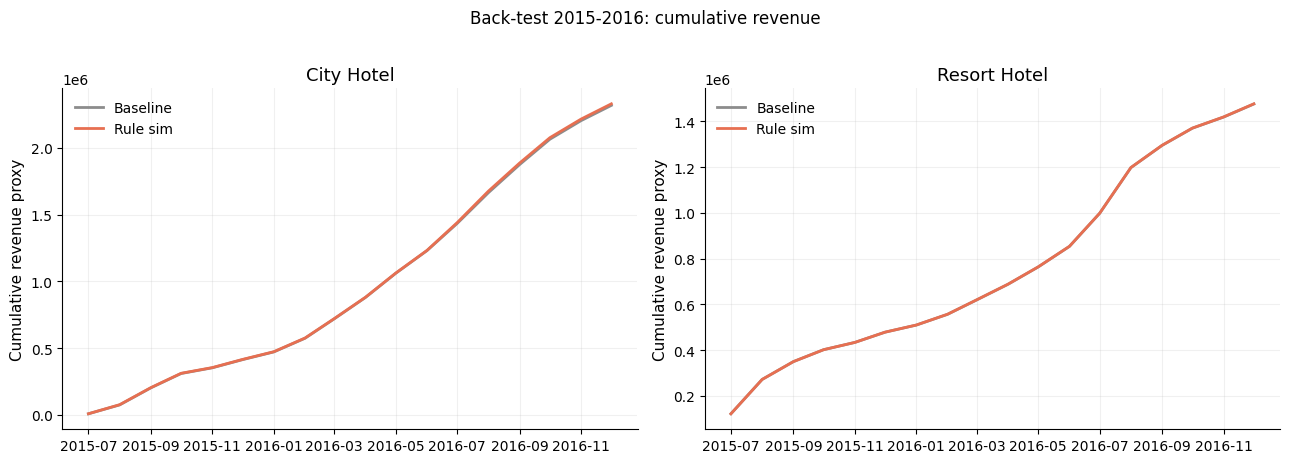

Saved: reports\figures\27_validate_simulation\compare\10_backtest_cum_revenue.png


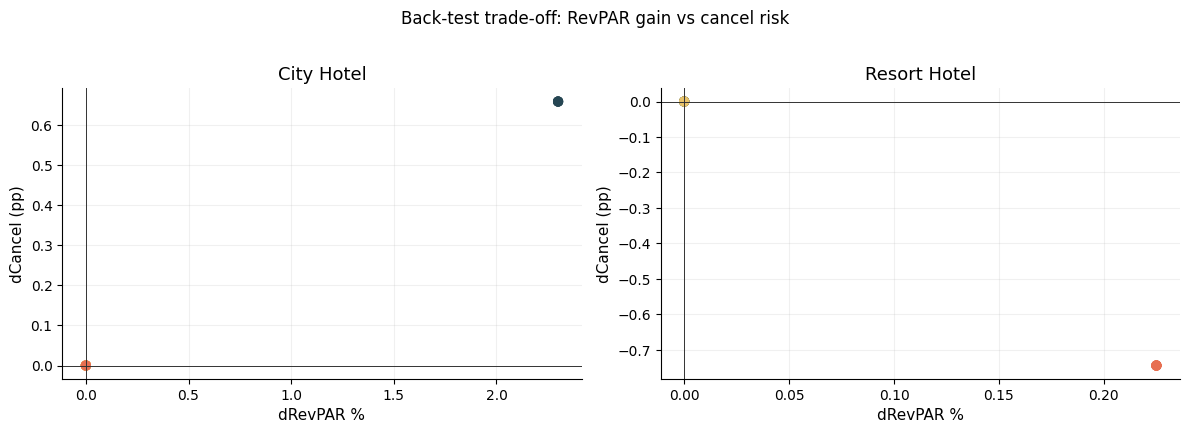

Saved: reports\figures\27_validate_simulation\compare\11_backtest_revpar_vs_cancel.png


,hotel,mean_delta_revpar_all,mean_delta_revpar_peak,mean_delta_cancel_pp,win_rate,pass_revpar,pass_peak_city,pass_cancel,go
0,City Hotel,0.511,2.3,0.147,0.222,True,True,True,True
1,Resort Hotel,0.088,0.0,-0.290,0.389,True,True,True,True


In [8]:
def rule_multiplier(hotel: str, season: str) -> float:
    if hotel == "City Hotel" and season == "Peak":
        return 1.10
    if hotel == "Resort Hotel" and season == "Low":
        return 0.95
    return 1.00


bt_rows = []
mask = (panel["ym"] >= "2015-07-01") & (panel["ym"] <= "2016-12-01")
bt_panel = panel.loc[mask].copy()

for _, r in bt_panel.iterrows():
    hotel, season = r["hotel"], r["season"]
    eps = EPS_PRIOR[hotel]
    p0, q0 = float(r["adr"]), float(r["demand"])
    mult = rule_multiplier(hotel, season)
    p_rule = p0 * mult
    rev_rule, q_rule = revenue_at(p_rule, p0, q0, eps)
    occ0 = float(r["occ"])
    revpar_base = p0 * occ0
    occ_rule = float(np.clip(occ0 * (q_rule / q0), 0.05, 0.99))
    revpar_rule = p_rule * occ_rule
    slope = risk_slope[hotel]
    risk_rule = float(np.clip(r["cancel_rate"] + slope * np.log(max(p_rule / p0, 1e-9)), 0.01, 0.95))
    bt_rows.append({
        "hotel": hotel,
        "ym": r["ym"],
        "season": season,
        "rule_mult": mult,
        "action": action_from_delta((mult - 1) * 100),
        "adr_base": p0,
        "adr_rule": p_rule,
        "revpar_panel": float(r["revpar"]),
        "revpar_base": revpar_base,
        "revpar_rule": revpar_rule,
        "delta_revpar_pct": (revpar_rule / revpar_base - 1) * 100 if revpar_base else np.nan,
        "cancel_base": float(r["cancel_rate"]),
        "cancel_rule": risk_rule,
        "delta_cancel_pp": (risk_rule - r["cancel_rate"]) * 100,
        "rev_base": p0 * q0,
        "rev_rule": float(rev_rule),
        "delta_rev_pct": (rev_rule / (p0 * q0) - 1) * 100,
    })

bt = pd.DataFrame(bt_rows)
bt.to_csv(FIG_DIR / "tables" / "backtest_2015_2016_monthly.csv", index=False)

bt_sum = (
    bt.groupby(["hotel", "season"], as_index=False)
    .agg(
        n=("ym", "size"),
        mean_delta_revpar=("delta_revpar_pct", "mean"),
        mean_delta_rev=("delta_rev_pct", "mean"),
        mean_delta_cancel_pp=("delta_cancel_pp", "mean"),
        win_rate=("delta_revpar_pct", lambda s: (s > 0).mean()),
    )
)
display(bt_sum.round(2))
bt_sum.to_csv(FIG_DIR / "tables" / "backtest_2015_2016_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, hotel in zip(axes, HOTELS):
    sub = bt[bt["hotel"] == hotel].sort_values("ym")
    ax.plot(sub["ym"], sub["rev_base"].cumsum(), color=BASE, lw=2, label="Baseline")
    ax.plot(sub["ym"], sub["rev_rule"].cumsum(), color=OUR, lw=2, label="Rule sim")
    ax.set_title(hotel)
    ax.set_ylabel("Cumulative revenue proxy")
    ax.legend(frameon=False)
fig.suptitle("Back-test 2015-2016: cumulative revenue", y=1.02)
savefig("10_backtest_cum_revenue.png", "compare")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, hotel in zip(axes, HOTELS):
    sub = bt[bt["hotel"] == hotel]
    c = [
        COLORS["teal"] if s == "Peak" else (COLORS["coral"] if s == "Low" else COLORS["gold"])
        for s in sub["season"]
    ]
    ax.scatter(sub["delta_revpar_pct"], sub["delta_cancel_pp"], c=c, s=40)
    ax.axhline(0, color="#333", lw=0.7)
    ax.axvline(0, color="#333", lw=0.7)
    ax.set_xlabel("dRevPAR %")
    ax.set_ylabel("dCancel (pp)")
    ax.set_title(hotel)
fig.suptitle("Back-test trade-off: RevPAR gain vs cancel risk", y=1.02)
savefig("11_backtest_revpar_vs_cancel.png", "compare")

gates = []
for hotel in HOTELS:
    sub = bt[bt["hotel"] == hotel]
    peak = sub[sub["season"] == "Peak"]
    gates.append({
        "hotel": hotel,
        "mean_delta_revpar_all": sub["delta_revpar_pct"].mean(),
        "mean_delta_revpar_peak": peak["delta_revpar_pct"].mean() if len(peak) else np.nan,
        "mean_delta_cancel_pp": sub["delta_cancel_pp"].mean(),
        "win_rate": (sub["delta_revpar_pct"] > 0).mean(),
        "pass_revpar": bool(sub["delta_revpar_pct"].mean() >= 0),
        "pass_peak_city": bool(hotel != "City Hotel" or (len(peak) and peak["delta_revpar_pct"].mean() >= 0)),
        "pass_cancel": bool(sub["delta_cancel_pp"].mean() <= 1.0),
    })
gates_df = pd.DataFrame(gates)
gates_df["go"] = gates_df["pass_revpar"] & gates_df["pass_peak_city"] & gates_df["pass_cancel"]
display(gates_df.round(3))
gates_df.to_csv(FIG_DIR / "tables" / "backtest_go_nogo.csv", index=False)


## 6. Export pack (report later)


In [9]:
manifest = pd.DataFrame({
    "artifact": sorted(str(p.relative_to(ROOT)) for p in FIG_DIR.rglob("*") if p.is_file()),
})
display(manifest)
manifest.to_csv(FIG_DIR / "tables" / "artifact_manifest.csv", index=False)
print("\n=== DONE notebook 27 analysis ===")
print(f"Figures/tables -> {FIG_DIR.relative_to(ROOT)}")


,artifact
0,reports\figures\27_validate_simulation\compare...
1,reports\figures\27_validate_simulation\compare...
2,reports\figures\27_validate_simulation\compare...
3,reports\figures\27_validate_simulation\compare...
4,reports\figures\27_validate_simulation\compare...
5,reports\figures\27_validate_simulation\compare...
6,reports\figures\27_validate_simulation\compare...
7,reports\figures\27_validate_simulation\compare...
8,reports\figures\27_validate_simulation\compare...
9,reports\figures\27_validate_simulation\compare...



=== DONE notebook 27 analysis ===
Figures/tables -> reports\figures\27_validate_simulation
